# Chapter 07: Transformation Matrices

Source orientation: *Fundamentals of Computer Graphics*, Chapter 7, printed pages 127-156, physical PDF pages 144-173. This notebook is standalone: it uses the assigned span only to choose the ideas and terminology, then builds original computational examples and artifacts.

## Chapter Goal

Transformation matrices are the bookkeeping system that lets a graphics program place models, compose object edits, move between coordinate frames, and keep geometric quantities such as normals meaningful after deformation. By the end of this chapter notebook, you should be able to read a matrix as a geometric operation, predict how composition order changes the result, choose the right homogeneous representation for a point or a direction, invert common graphics transforms, and diagnose when a normal vector needs the inverse-transpose transform.

## Translation guide

| Book idea | Computational object in this notebook | Geometry to inspect |
| --- | --- | --- |
| 2D linear transformation | `2 x 2` NumPy matrix applied to columns | basis vectors move to the matrix columns; signed area scales by determinant |
| Scale, shear, rotation, reflection | named matrix constructors | circles become ellipses, orientation may flip, rotations preserve length and angle |
| Composition | matrix products applied right-to-left | `R @ S @ p` means scale first, then rotate |
| Decomposition | eigen-decomposition and SVD | an arbitrary linear map can be inspected as rotate-scale-rotate; symmetric maps reuse one axis frame |
| Homogeneous coordinates | `3 x 3` or `4 x 4` matrices with a final coordinate | `w=1` means point, `w=0` means direction; translation affects only points |
| 3D rotations and frames | orthonormal bases stored as matrix columns or rows | a basis matrix is a coordinate converter and its transpose is the inverse when orthonormal |
| Normal vectors | inverse-transpose of the linear part | tangents transform by `M`; normals must keep zero dot product with every transformed tangent |

## Visual storyboard

The notebook follows a single diagnostic thread: start with a simple shape and its basis vectors, compose operations in both orders, decompose linear maps into inspectable rotations and scales, add homogeneous coordinates for translation, lift the ideas into 3D frames, then finish with two failure modes that show up constantly in graphics code: using the wrong normal transform and mixing coordinate frames. Each saved artifact has a named invariant next to it, and the final sanity checks rerun the core matrix identities.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root from the current working directory.")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_close, assert_nonblank_image
from utils.plotting import PALETTE, add_note, close, style_axis
from utils.transforms import rotation2, scale2, shear2

TOPIC = "chapter-07"
ARTIFACTS: list[Path] = []
CHECKS: dict[str, object] = {}
np.set_printoptions(precision=4, suppress=True)

## 1. Linear maps move the basis first

A `2 x 2` matrix is easiest to read by applying it to the two canonical basis vectors. The first column is where `(1,0)` lands; the second column is where `(0,1)` lands. Once those two arrows are known, every other point follows by the same linear combination.

The figure below uses a small synthetic marker, not a textbook figure: a polygonal tile, a circular guide, and two basis arrows. The inspection target is the pair of transformed basis arrows. The invariant is signed area scale: for any region transformed by a linear map `A`, oriented area is multiplied by `det(A)`. A negative determinant signals an orientation flip.

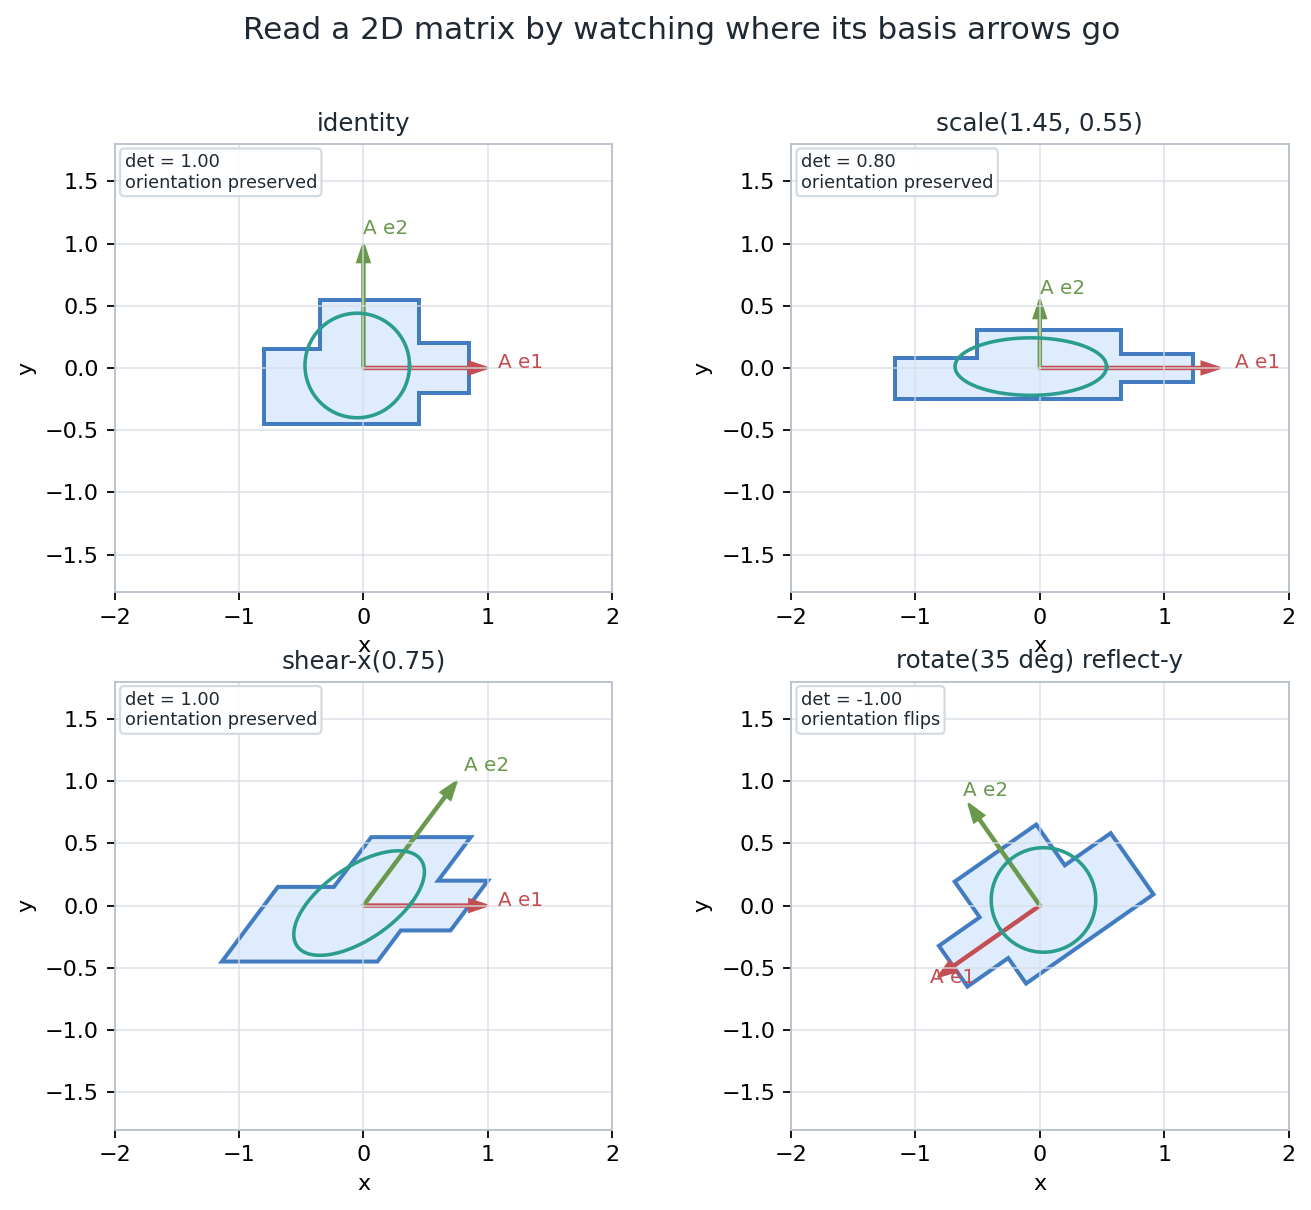

In [2]:
def apply_linear(A: np.ndarray, points: np.ndarray) -> np.ndarray:
    return (A @ points.T).T


def make_marker() -> dict[str, np.ndarray]:
    # A deliberately asymmetric marker makes rotations, reflections, and shears easy to tell apart.
    body = np.array([
        [-0.80, -0.45], [0.45, -0.45], [0.45, -0.20], [0.85, -0.20],
        [0.85, 0.20], [0.45, 0.20], [0.45, 0.55], [-0.35, 0.55],
        [-0.35, 0.15], [-0.80, 0.15], [-0.80, -0.45],
    ])
    t = np.linspace(0, 2 * np.pi, 220)
    circle = np.column_stack([0.42 * np.cos(t) - 0.05, 0.42 * np.sin(t) + 0.02])
    return {"body": body, "circle": circle}


def draw_linear_panel(ax, A: np.ndarray, title: str, note: str = "") -> None:
    marker = make_marker()
    for name, pts in marker.items():
        transformed = apply_linear(A, pts)
        if name == "body":
            ax.fill(transformed[:, 0], transformed[:, 1], color="#dbeafe", edgecolor=PALETTE["blue"], linewidth=1.8, alpha=0.9)
        else:
            ax.plot(transformed[:, 0], transformed[:, 1], color=PALETTE["teal"], linewidth=1.6)
    origin = np.zeros(2)
    e1 = A @ np.array([1.0, 0.0])
    e2 = A @ np.array([0.0, 1.0])
    ax.arrow(*origin, *e1, width=0.018, head_width=0.10, length_includes_head=True, color=PALETTE["red"])
    ax.arrow(*origin, *e2, width=0.018, head_width=0.10, length_includes_head=True, color=PALETTE["green"])
    ax.text(*(e1 * 1.08), "A e1", color=PALETTE["red"], fontsize=9)
    ax.text(*(e2 * 1.08), "A e2", color=PALETTE["green"], fontsize=9)
    style_axis(ax, title, equal=True, xlabel="x", ylabel="y")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-1.8, 1.8)
    det = np.linalg.det(A)
    add_note(ax, f"det = {det:.2f}\n{note}")


transforms_2d = {
    "identity": np.eye(2),
    "scale(1.45, 0.55)": scale2(1.45, 0.55),
    "shear-x(0.75)": shear2(kx=0.75),
    "rotate(35 deg) reflect-y": rotation2(np.deg2rad(35)) @ np.array([[-1.0, 0.0], [0.0, 1.0]]),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (title, A) in zip(axes.ravel(), transforms_2d.items()):
    sign_note = "orientation flips" if np.linalg.det(A) < 0 else "orientation preserved"
    draw_linear_panel(ax, A, title, sign_note)
fig.suptitle("Read a 2D matrix by watching where its basis arrows go", fontsize=14, color=PALETTE["ink"])
linear_path = save_matplotlib(fig, TOPIC, "linear-map-basis-area.png")
close(fig)
ARTIFACTS.append(linear_path)

det_checks = {name: float(np.linalg.det(A)) for name, A in transforms_2d.items()}
rotation = rotation2(np.deg2rad(35))
linear_checks = {
    "determinants": det_checks,
    "rotation_orthogonality_error": float(np.linalg.norm(rotation.T @ rotation - np.eye(2))),
    "basis_column_rule_error": float(np.linalg.norm(transforms_2d["shear-x(0.75)"][:, 0] - transforms_2d["shear-x(0.75)"] @ np.array([1.0, 0.0]))),
}
assert linear_checks["rotation_orthogonality_error"] < 1e-12
assert det_checks["rotate(35 deg) reflect-y"] < 0
linear_check_path = save_json(linear_checks, TOPIC, "linear-transform-invariants.json")
ARTIFACTS.append(linear_check_path)

display_artifact(linear_path, width=760)
display_artifact(linear_check_path)
CHECKS["linear"] = linear_checks

## 2. Composition order is part of the transform

Column-vector graphics notation applies the rightmost matrix first. If `S` scales and `R` rotates, then `R @ S @ p` means "scale the point, then rotate the result." Reversing the order changes the geometry unless the two matrices happen to commute.

This is the most common source of visual bugs in transformation code. The figure below shows the same marker under `R @ S` and `S @ R`. Both have the same determinant because determinant is multiplicative, but the stretched axis is different.

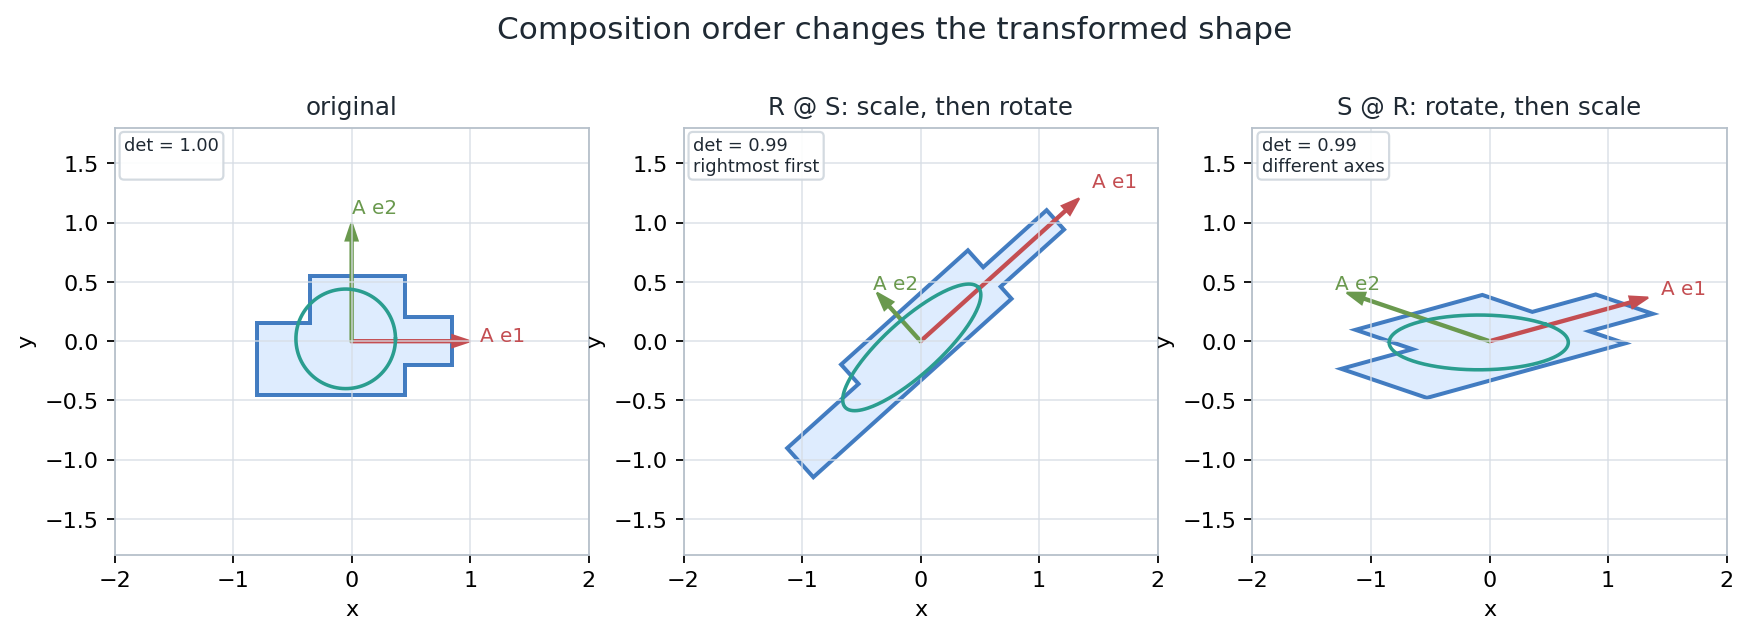

Symbolic commutator `R S - S R` is `\left[\begin{matrix}0 & s \left(sx - sy\right)\\s \left(sx - sy\right) & 0\end{matrix}\right]`. It vanishes for uniform scale or zero rotation sine, not in general.

In [3]:
theta = np.deg2rad(42)
R = rotation2(theta)
S = scale2(1.8, 0.55)
RS = R @ S
SR = S @ R

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
draw_linear_panel(axes[0], np.eye(2), "original")
draw_linear_panel(axes[1], RS, "R @ S: scale, then rotate", "rightmost first")
draw_linear_panel(axes[2], SR, "S @ R: rotate, then scale", "different axes")
fig.suptitle("Composition order changes the transformed shape", fontsize=14, color=PALETTE["ink"])
composition_path = save_matplotlib(fig, TOPIC, "composition-order-noncommuting.png")
close(fig)
ARTIFACTS.append(composition_path)

sx, sy, c, s = sp.symbols("sx sy c s")
Ssym = sp.Matrix([[sx, 0], [0, sy]])
Rsym = sp.Matrix([[c, -s], [s, c]])
commutator = sp.simplify(Rsym * Ssym - Ssym * Rsym)
expected_commutator = sp.Matrix([[0, s * (sx - sy)], [s * (sx - sy), 0]])
assert sp.simplify(commutator - expected_commutator) == sp.zeros(2)

sample = np.array([0.65, 0.45])
composition_checks = {
    "commutator_symbolic": str(commutator),
    "RS_minus_SR_frobenius": float(np.linalg.norm(RS - SR)),
    "same_area_scale": float(abs(np.linalg.det(RS) - np.linalg.det(SR))),
    "sample_point_difference": float(np.linalg.norm(RS @ sample - SR @ sample)),
}
assert composition_checks["RS_minus_SR_frobenius"] > 0.5
assert composition_checks["same_area_scale"] < 1e-12
composition_check_path = save_json(composition_checks, TOPIC, "composition-order-checks.json")
ARTIFACTS.append(composition_check_path)

rows = [
    {"expression": "R @ S @ p", "rightmost_operation": "scale", "second_operation": "rotate", "determinant": np.linalg.det(RS)},
    {"expression": "S @ R @ p", "rightmost_operation": "rotate", "second_operation": "scale", "determinant": np.linalg.det(SR)},
]
composition_table_path = save_table_csv(rows, TOPIC, "composition-order-diagnostics.csv")
ARTIFACTS.append(composition_table_path)

display_artifact(composition_path, width=900)
display(Markdown(f"Symbolic commutator `R S - S R` is `{sp.latex(commutator)}`. It vanishes for uniform scale or zero rotation sine, not in general."))
display_artifact(composition_table_path)
CHECKS["composition"] = composition_checks

## 3. Decomposition turns a matrix into inspectable rotations and scales

The source chapter emphasizes two related factorizations. A symmetric matrix has an eigen-decomposition `A = R S R.T`, which means it scales along perpendicular directions and then rotates back. A general matrix has an SVD `A = U S V.T`, which means rotate one basis to the coordinate axes, scale, and rotate to another basis.

The plot below maps the unit circle. The symmetric example has one pair of principal axes; the shear example needs different right and left singular vector frames. The invariant is reconstruction error: multiplying the factors must rebuild the original matrix within numerical tolerance.

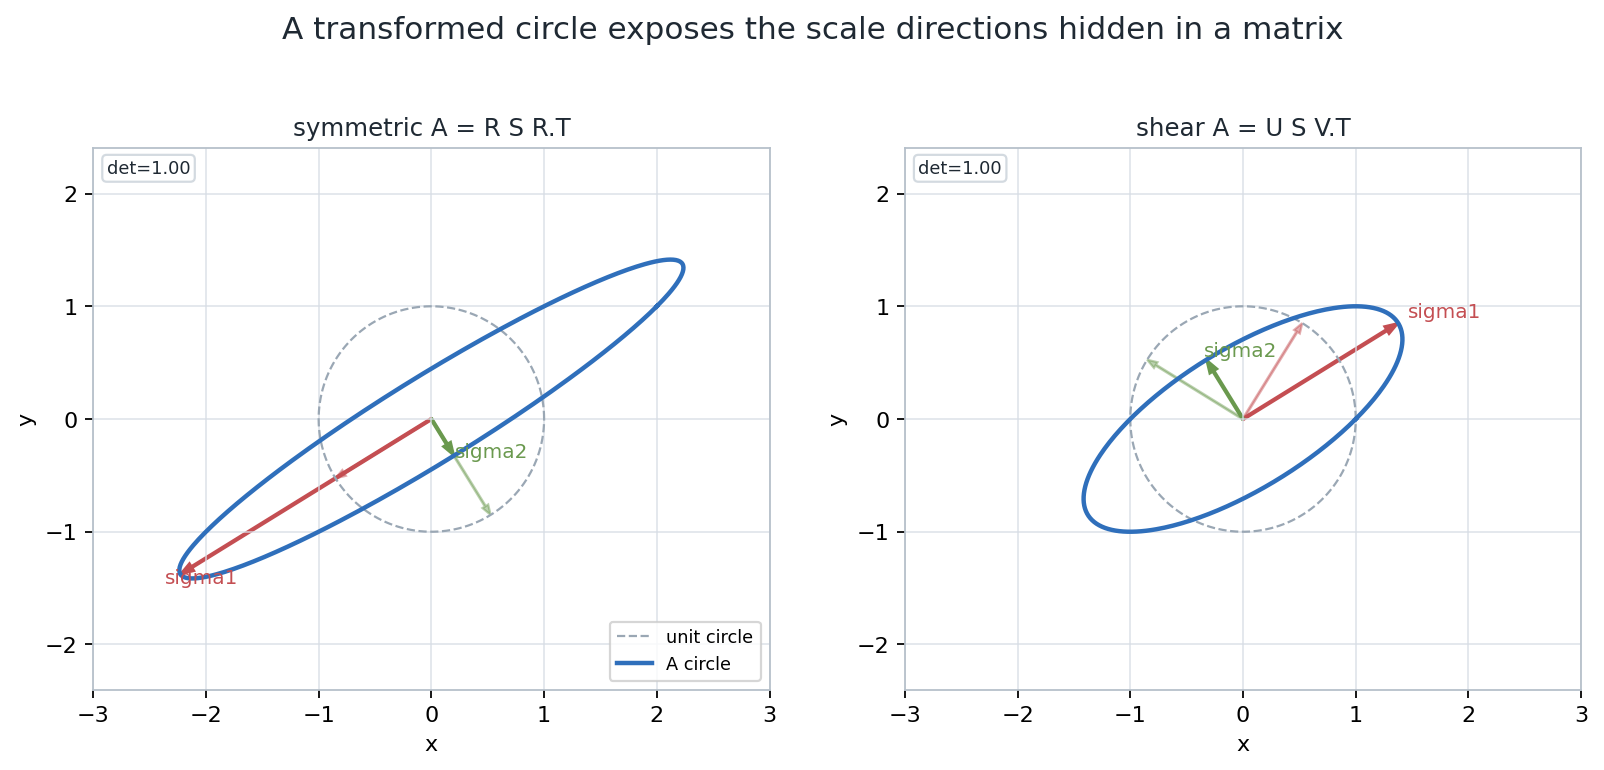

In [4]:
def unit_circle(n=320) -> np.ndarray:
    t = np.linspace(0, 2 * np.pi, n)
    return np.column_stack([np.cos(t), np.sin(t)])


def draw_decomposition(ax, A: np.ndarray, title: str, vectors_in: np.ndarray, vectors_out: np.ndarray, scales: np.ndarray) -> None:
    circle = unit_circle()
    mapped = apply_linear(A, circle)
    ax.plot(circle[:, 0], circle[:, 1], color="#9aa7b4", linestyle="--", linewidth=1.0, label="unit circle")
    ax.plot(mapped[:, 0], mapped[:, 1], color=PALETTE["blue"], linewidth=2.0, label="A circle")
    for idx, color in enumerate([PALETTE["red"], PALETTE["green"]]):
        vin = vectors_in[:, idx]
        vout = vectors_out[:, idx] * scales[idx]
        ax.arrow(0, 0, vin[0], vin[1], width=0.01, head_width=0.06, color=color, alpha=0.45, length_includes_head=True)
        ax.arrow(0, 0, vout[0], vout[1], width=0.018, head_width=0.08, color=color, length_includes_head=True)
        ax.text(vout[0] * 1.06, vout[1] * 1.06, f"sigma{idx+1}", color=color, fontsize=9)
    style_axis(ax, title, equal=True, xlabel="x", ylabel="y")
    ax.set_xlim(-3.0, 3.0)
    ax.set_ylim(-2.4, 2.4)
    add_note(ax, f"det={np.linalg.det(A):.2f}")


symmetric_A = np.array([[2.0, 1.0], [1.0, 1.0]])
shear_A = shear2(kx=1.0)

evals, Q = np.linalg.eigh(symmetric_A)
order = np.argsort(evals)[::-1]
evals = evals[order]
Q = Q[:, order]
if np.linalg.det(Q) < 0:
    Q[:, -1] *= -1
sym_recon = Q @ np.diag(evals) @ Q.T

U_raw, singular_values_raw, Vt_raw = np.linalg.svd(shear_A)
svd_recon_raw = U_raw @ np.diag(singular_values_raw) @ Vt_raw
U = U_raw.copy()
singular_values = singular_values_raw.copy()
V = Vt_raw.T.copy()
if np.linalg.det(U) < 0:
    U[:, -1] *= -1
    singular_values[-1] *= -1

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
draw_decomposition(axes[0], symmetric_A, "symmetric A = R S R.T", Q, Q, evals)
draw_decomposition(axes[1], shear_A, "shear A = U S V.T", V, U, singular_values)
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("A transformed circle exposes the scale directions hidden in a matrix", fontsize=14, color=PALETTE["ink"])
decomposition_path = save_matplotlib(fig, TOPIC, "decomposition-unit-circle-diagnostics.png")
close(fig)
ARTIFACTS.append(decomposition_path)

decomposition_checks = {
    "symmetric_eigenvalues": [float(x) for x in evals],
    "symmetric_reconstruction_error": float(np.linalg.norm(sym_recon - symmetric_A)),
    "shear_singular_values": [float(x) for x in singular_values_raw],
    "shear_svd_reconstruction_error": float(np.linalg.norm(svd_recon_raw - shear_A)),
    "shear_condition_number": float(singular_values_raw[0] / singular_values_raw[-1]),
}
assert decomposition_checks["symmetric_reconstruction_error"] < 1e-12
assert decomposition_checks["shear_svd_reconstruction_error"] < 1e-12
decomposition_check_path = save_json(decomposition_checks, TOPIC, "decomposition-checks.json")
ARTIFACTS.append(decomposition_check_path)

display_artifact(decomposition_path, width=860)
display_artifact(decomposition_check_path)
CHECKS["decomposition"] = decomposition_checks

## 4. Homogeneous coordinates distinguish points from directions

A `2 x 2` linear transform cannot translate the origin. Homogeneous coordinates add a final coordinate so translation can be handled by matrix multiplication. The added coordinate is not decoration: `w=1` means the vector represents a location, while `w=0` means it represents an offset or direction. A translation column is multiplied by `w`, so it affects points and ignores directions.

The figure below shows the same numeric pair `(x,y)` encoded both ways. The point moves under translation; the direction arrow does not. The symbolic check under the figure proves that the behavior is structural, not a special numeric accident.

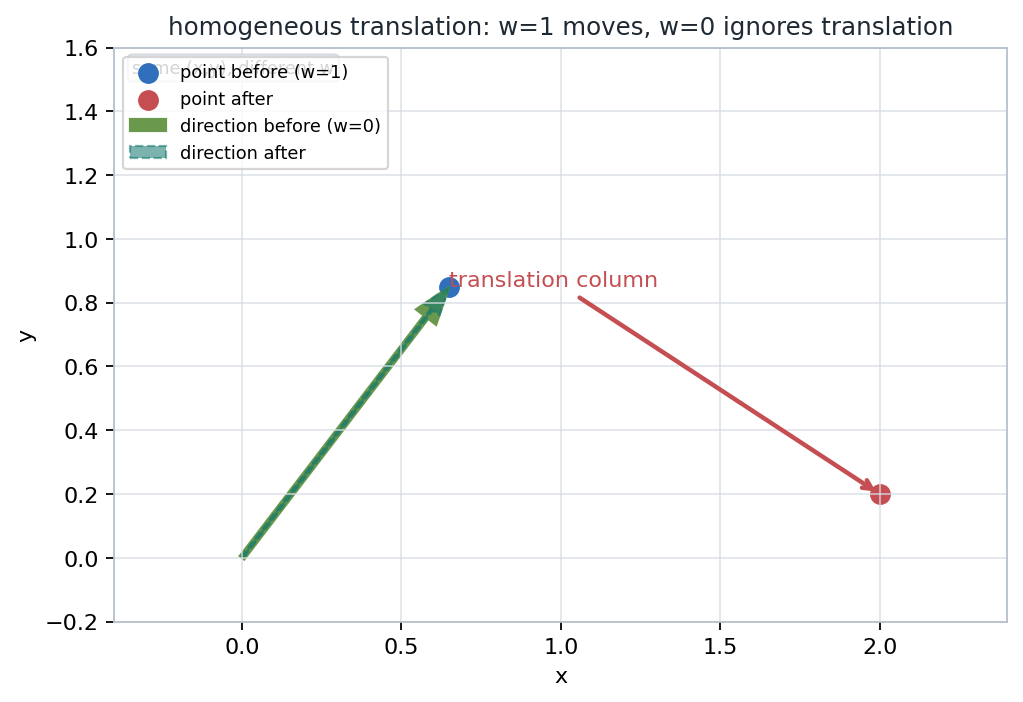

Symbolically, `T [x, y, 1]^T = \left[\begin{matrix}tx + x\\ty + y\\1\end{matrix}\right]` but `T [x, y, 0]^T = \left[\begin{matrix}x\\y\\0\end{matrix}\right]`.

In [5]:
T2 = np.array([[1.0, 0.0, 1.35], [0.0, 1.0, -0.65], [0.0, 0.0, 1.0]])
point_xy = np.array([0.65, 0.85, 1.0])
direction_xy = np.array([0.65, 0.85, 0.0])
point_moved = T2 @ point_xy
direction_moved = T2 @ direction_xy

fig, ax = plt.subplots(figsize=(7.2, 5.6))
style_axis(ax, "homogeneous translation: w=1 moves, w=0 ignores translation", equal=True, xlabel="x", ylabel="y")
ax.set_xlim(-0.4, 2.4)
ax.set_ylim(-0.2, 1.6)
ax.scatter([point_xy[0]], [point_xy[1]], color=PALETTE["blue"], s=70, label="point before (w=1)")
ax.scatter([point_moved[0]], [point_moved[1]], color=PALETTE["red"], s=70, label="point after")
ax.annotate("translation column", xy=(point_moved[0], point_moved[1]), xytext=(point_xy[0], point_xy[1]), arrowprops={"arrowstyle": "->", "color": PALETTE["red"], "linewidth": 2}, color=PALETTE["red"])
ax.arrow(0, 0, direction_xy[0], direction_xy[1], width=0.018, head_width=0.08, length_includes_head=True, color=PALETTE["green"], label="direction before (w=0)")
ax.arrow(0, 0, direction_moved[0], direction_moved[1], width=0.009, head_width=0.06, length_includes_head=True, color="#0f766e", linestyle="--", alpha=0.55, label="direction after")
ax.legend(loc="upper left", fontsize=8)
add_note(ax, "same (x,y), different w")
homogeneous_path = save_matplotlib(fig, TOPIC, "homogeneous-point-vector-translation.png")
close(fig)
ARTIFACTS.append(homogeneous_path)

x, y, tx, ty = sp.symbols("x y tx ty")
Tsym = sp.Matrix([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
point_sym = sp.Matrix([x, y, 1])
vector_sym = sp.Matrix([x, y, 0])
point_expr = Tsym * point_sym
vector_expr = Tsym * vector_sym
assert point_expr == sp.Matrix([x + tx, y + ty, 1])
assert vector_expr == vector_sym

homogeneous_checks = {
    "point_before": point_xy.tolist(),
    "point_after": point_moved.tolist(),
    "direction_after": direction_moved.tolist(),
    "translation_ignored_by_w_zero": bool(np.allclose(direction_moved, direction_xy)),
    "symbolic_point_result": str(point_expr),
    "symbolic_vector_result": str(vector_expr),
}
homogeneous_check_path = save_json(homogeneous_checks, TOPIC, "homogeneous-coordinate-checks.json")
ARTIFACTS.append(homogeneous_check_path)

display_artifact(homogeneous_path, width=680)
display(Markdown(f"Symbolically, `T [x, y, 1]^T = {sp.latex(point_expr)}` but `T [x, y, 0]^T = {sp.latex(vector_expr)}`."))
CHECKS["homogeneous"] = homogeneous_checks

## 5. 3D rotations are coordinate-frame operations

In 3D there is no single rotation angle without an axis or a frame. One constructive route is: build an orthonormal basis whose third vector is the desired axis, rotate around the canonical `z` axis, and convert back. Algebraically that is a change of basis around a simple rotation.

The interactive Plotly artifact shows a small wire cube, a rotation axis, and the before/after basis arrows. Rotate the view and inspect the axis: it stays fixed while vectors perpendicular to the axis sweep around it. The invariant is that the rotation matrix is orthogonal and has determinant `+1`.

In [6]:
def normalize(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("zero vector cannot be normalized")
    return v / n


def basis_from_axis(axis: np.ndarray) -> np.ndarray:
    w = normalize(axis)
    helper = np.array([1.0, 0.0, 0.0]) if abs(w[0]) < 0.85 else np.array([0.0, 1.0, 0.0])
    u = normalize(np.cross(helper, w))
    v = np.cross(w, u)
    return np.column_stack([u, v, w])


def rotate_z_3(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])


axis = normalize(np.array([0.75, 1.0, 0.55]))
B = basis_from_axis(axis)
phi = np.deg2rad(68)
R_axis = B @ rotate_z_3(phi) @ B.T

cube = np.array([
    [-0.45, -0.45, -0.45], [0.45, -0.45, -0.45], [0.45, 0.45, -0.45], [-0.45, 0.45, -0.45],
    [-0.45, -0.45, 0.45], [0.45, -0.45, 0.45], [0.45, 0.45, 0.45], [-0.45, 0.45, 0.45],
])
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
rot_cube = (R_axis @ cube.T).T

fig = go.Figure()
for pts, name, color in [(cube, "original cube", "rgba(47,111,187,0.50)"), (rot_cube, "rotated cube", "rgba(196,78,82,0.75)")]:
    for i, j in edges:
        fig.add_trace(go.Scatter3d(x=[pts[i, 0], pts[j, 0]], y=[pts[i, 1], pts[j, 1]], z=[pts[i, 2], pts[j, 2]], mode="lines", line={"color": color, "width": 5}, name=name, showlegend=(i, j) == edges[0]))

for vec, name, color in [(axis, "fixed rotation axis", "#111827"), (R_axis @ np.array([1, 0, 0]), "R e1", PALETTE["red"]), (R_axis @ np.array([0, 1, 0]), "R e2", PALETTE["green"]), (R_axis @ np.array([0, 0, 1]), "R e3", PALETTE["blue"])]:
    fig.add_trace(go.Scatter3d(x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]], mode="lines+markers", line={"color": color, "width": 7}, marker={"size": 3}, name=name))

fig.update_layout(
    title="Arbitrary-axis rotation as basis change, z-rotation, basis change back",
    scene={"xaxis_title": "x", "yaxis_title": "y", "zaxis_title": "z", "aspectmode": "cube"},
    margin={"l": 0, "r": 0, "b": 0, "t": 42},
    legend={"orientation": "h", "y": -0.05},
)
axis_html_path = save_plotly_html(fig, TOPIC, "axis-frame-rotation-3d.html")
ARTIFACTS.append(axis_html_path)

axis_checks = {
    "axis": axis.tolist(),
    "orthogonality_error": float(np.linalg.norm(R_axis.T @ R_axis - np.eye(3))),
    "determinant": float(np.linalg.det(R_axis)),
    "axis_fixed_error": float(np.linalg.norm(R_axis @ axis - axis)),
}
assert axis_checks["orthogonality_error"] < 1e-12
assert abs(axis_checks["determinant"] - 1.0) < 1e-12
assert axis_checks["axis_fixed_error"] < 1e-12
axis_check_path = save_json(axis_checks, TOPIC, "axis-rotation-checks.json")
ARTIFACTS.append(axis_check_path)

display_artifact(axis_html_path, width="100%", height=520)
display_artifact(axis_check_path)
CHECKS["axis_rotation"] = axis_checks

## 6. Normals do not transform like ordinary directions

Tangents follow the surface points: if a surface is transformed by `M`, a tangent vector `t` becomes `M t`. A normal is different because its job is to remain perpendicular to the transformed tangent plane. Under nonuniform scale or shear, `M n` is usually not perpendicular to that plane.

The correct normal matrix is `(M^-1).T`, applied to the original normal and then renormalized if a unit normal is needed. The proof scaffold is the zero dot product: if `n.T t = 0`, then `((M^-1).T n).T (M t) = n.T t = 0`.

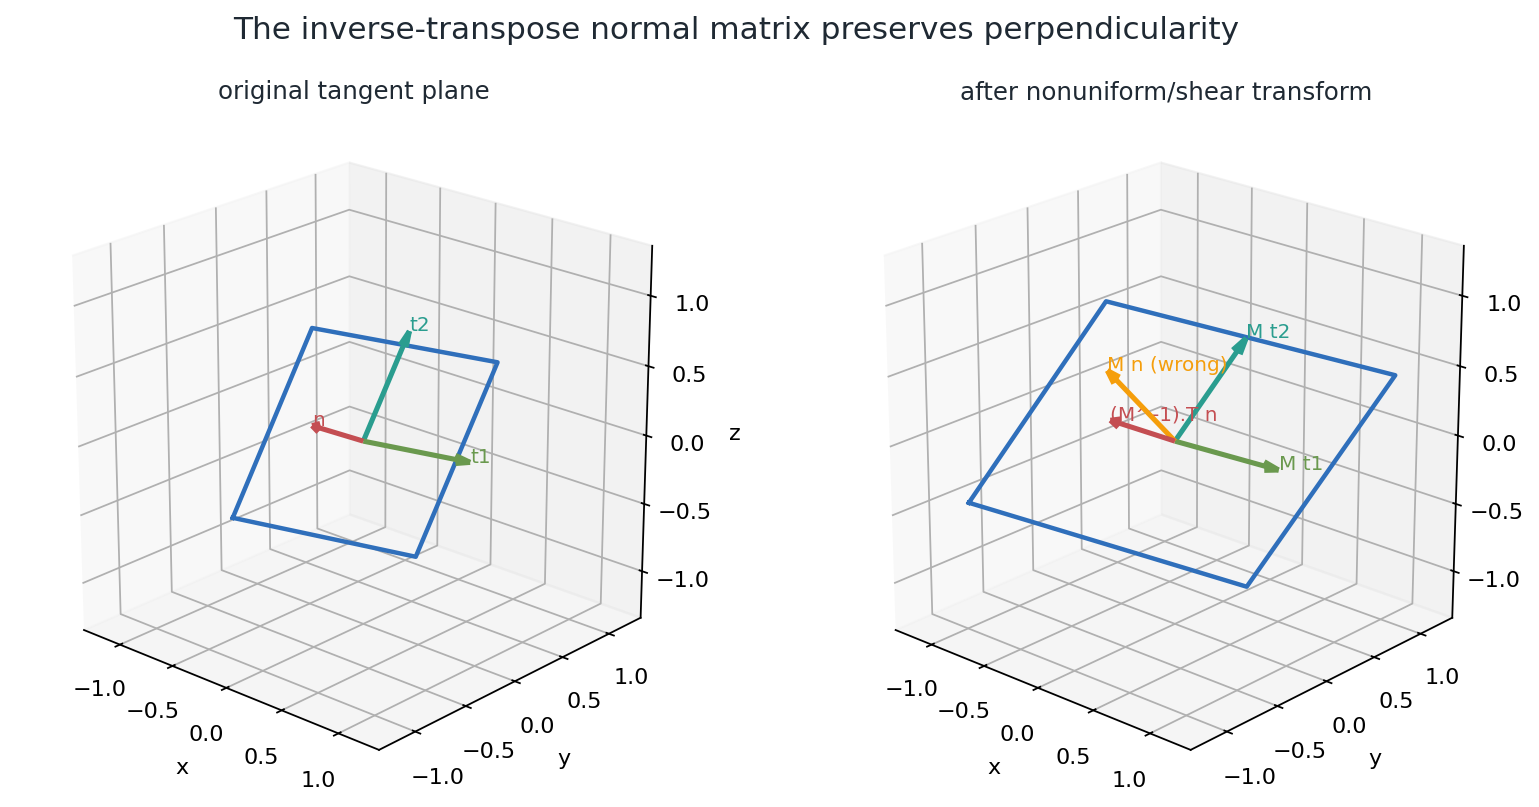

In [7]:
def plane_patch(t1: np.ndarray, t2: np.ndarray, scale: float = 0.7) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    grid = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1], [-1, -1]], dtype=float) * scale
    pts = np.outer(grid[:, 0], t1) + np.outer(grid[:, 1], t2)
    return pts[:, 0], pts[:, 1], pts[:, 2]


def draw_vec3(ax, v, label, color, origin=np.zeros(3), length=1.0):
    vv = normalize(v) * length
    ax.quiver(origin[0], origin[1], origin[2], vv[0], vv[1], vv[2], color=color, linewidth=2.3, arrow_length_ratio=0.14)
    tip = origin + vv
    ax.text(tip[0], tip[1], tip[2], label, color=color, fontsize=9)


t1 = normalize(np.array([1.0, 0.25, 0.0]))
t2 = normalize(np.array([0.10, 0.55, 1.0]))
n = normalize(np.cross(t1, t2))
M3 = np.array([[1.6, 0.55, 0.0], [0.0, 0.65, 0.30], [0.0, 0.0, 1.15]])
normal_matrix = np.linalg.inv(M3).T
Mt1 = M3 @ t1
Mt2 = M3 @ t2
wrong_n = M3 @ n
correct_n = normal_matrix @ n

fig = plt.figure(figsize=(12, 5.6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

for ax, title in [(ax1, "original tangent plane"), (ax2, "after nonuniform/shear transform")]:
    ax.set_title(title, fontsize=11, color=PALETTE["ink"])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-48)

x0, y0, z0 = plane_patch(t1, t2)
ax1.plot(x0, y0, z0, color=PALETTE["blue"], linewidth=2)
draw_vec3(ax1, t1, "t1", PALETTE["green"], length=0.8)
draw_vec3(ax1, t2, "t2", PALETTE["teal"], length=0.8)
draw_vec3(ax1, n, "n", PALETTE["red"], length=0.8)

x1, y1, z1 = plane_patch(Mt1, Mt2)
ax2.plot(x1, y1, z1, color=PALETTE["blue"], linewidth=2)
draw_vec3(ax2, Mt1, "M t1", PALETTE["green"], length=0.85)
draw_vec3(ax2, Mt2, "M t2", PALETTE["teal"], length=0.85)
draw_vec3(ax2, wrong_n, "M n (wrong)", "#f59e0b", length=0.8)
draw_vec3(ax2, correct_n, "(M^-1).T n", PALETTE["red"], length=0.8)

for ax in (ax1, ax2):
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_zlim(-1.35, 1.35)

fig.suptitle("The inverse-transpose normal matrix preserves perpendicularity", fontsize=14, color=PALETTE["ink"])
normal_path = save_matplotlib(fig, TOPIC, "normal-transform-inverse-transpose.png")
close(fig)
ARTIFACTS.append(normal_path)

normal_checks = {
    "original_dot_t1": float(np.dot(n, t1)),
    "original_dot_t2": float(np.dot(n, t2)),
    "wrong_dot_Mt1": float(np.dot(wrong_n, Mt1)),
    "wrong_dot_Mt2": float(np.dot(wrong_n, Mt2)),
    "correct_dot_Mt1": float(np.dot(correct_n, Mt1)),
    "correct_dot_Mt2": float(np.dot(correct_n, Mt2)),
}
assert abs(normal_checks["correct_dot_Mt1"]) < 1e-12
assert abs(normal_checks["correct_dot_Mt2"]) < 1e-12
assert max(abs(normal_checks["wrong_dot_Mt1"]), abs(normal_checks["wrong_dot_Mt2"])) > 0.05
normal_check_path = save_json(normal_checks, TOPIC, "normal-transform-checks.json")
ARTIFACTS.append(normal_check_path)

display_artifact(normal_path, width=880)
display_artifact(normal_check_path)
CHECKS["normal_transform"] = normal_checks

## 7. Coordinate frames: moving an object vs changing coordinates

A frame is an origin plus basis vectors. If a local 2D frame has origin `e` and basis vectors `u` and `v`, then a point with local coordinates `(a,b)` has canonical coordinates `e + a u + b v`. In homogeneous form, the frame-to-canonical matrix stores `u`, `v`, and `e` as columns.

The inverse matrix converts canonical coordinates back into the local frame. This is where many model, world, camera, and object-space bugs come from: a matrix that physically moves geometry in one interpretation is also a coordinate conversion in another interpretation, and the inverse goes the other way.

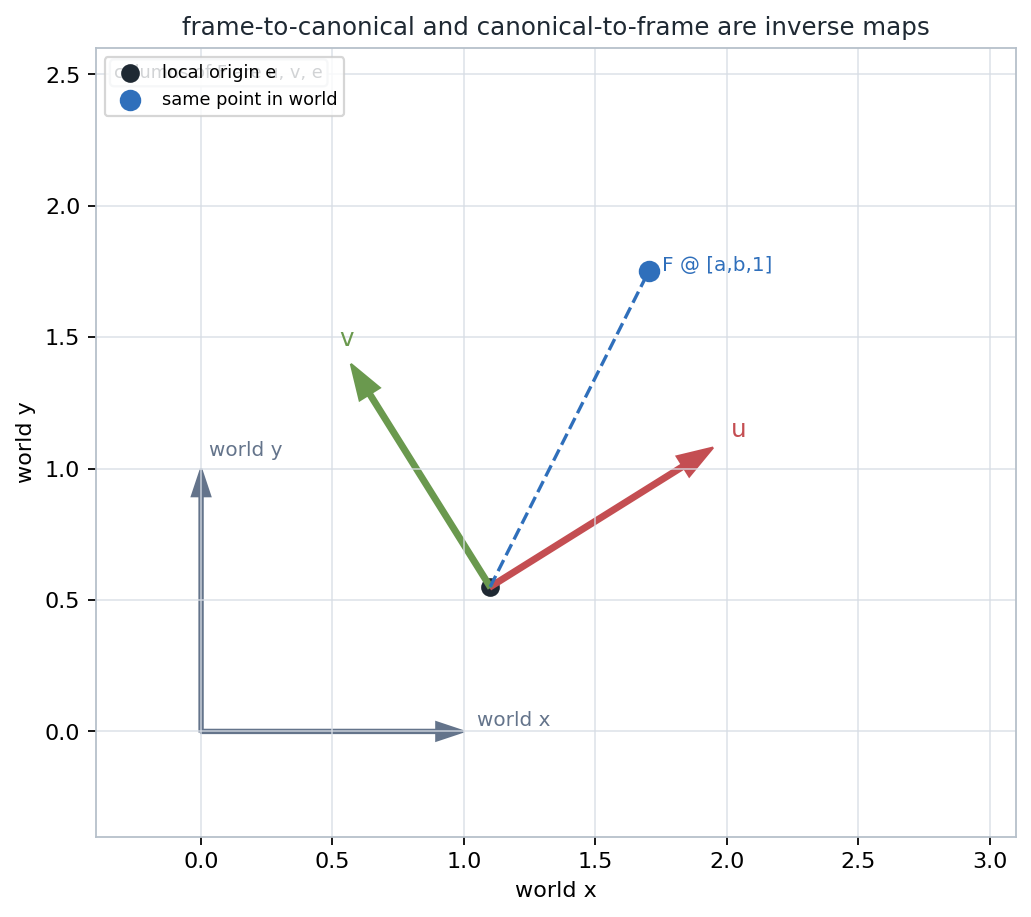

The same matrix can be read as placing the local frame into world space, or as converting local coordinates into world coordinates. Its inverse converts world coordinates back to the local frame.

In [8]:
e = np.array([1.1, 0.55])
angle = np.deg2rad(32)
u = rotation2(angle) @ np.array([1.0, 0.0])
v = rotation2(angle) @ np.array([0.0, 1.0])
F = np.array([[u[0], v[0], e[0]], [u[1], v[1], e[1]], [0.0, 0.0, 1.0]])
F_inv = np.linalg.inv(F)
local_p = np.array([1.15, 0.70, 1.0])
world_p = F @ local_p
roundtrip_p = F_inv @ world_p

fig, ax = plt.subplots(figsize=(7.8, 6.4))
style_axis(ax, "frame-to-canonical and canonical-to-frame are inverse maps", equal=True, xlabel="world x", ylabel="world y")
ax.set_xlim(-0.4, 3.1)
ax.set_ylim(-0.4, 2.6)
ax.arrow(0, 0, 1, 0, width=0.012, head_width=0.07, color="#64748b", length_includes_head=True)
ax.arrow(0, 0, 0, 1, width=0.012, head_width=0.07, color="#64748b", length_includes_head=True)
ax.text(1.05, 0.02, "world x", color="#64748b", fontsize=9)
ax.text(0.03, 1.05, "world y", color="#64748b", fontsize=9)
ax.scatter([e[0]], [e[1]], s=55, color=PALETTE["ink"], label="local origin e")
ax.arrow(e[0], e[1], u[0], u[1], width=0.018, head_width=0.09, color=PALETTE["red"], length_includes_head=True)
ax.arrow(e[0], e[1], v[0], v[1], width=0.018, head_width=0.09, color=PALETTE["green"], length_includes_head=True)
ax.text(*(e + 1.08 * u), "u", color=PALETTE["red"], fontsize=11)
ax.text(*(e + 1.08 * v), "v", color=PALETTE["green"], fontsize=11)
ax.scatter([world_p[0]], [world_p[1]], s=75, color=PALETTE["blue"], label="same point in world")
ax.plot([e[0], world_p[0]], [e[1], world_p[1]], color=PALETTE["blue"], linestyle="--", linewidth=1.5)
ax.text(world_p[0] + 0.05, world_p[1], "F @ [a,b,1]", color=PALETTE["blue"], fontsize=9)
add_note(ax, "columns of F are u, v, e")
ax.legend(loc="upper left", fontsize=8)
frame_path = save_matplotlib(fig, TOPIC, "coordinate-frame-inverse-map.png")
close(fig)
ARTIFACTS.append(frame_path)

frame_checks = {
    "frame_to_canonical": F.tolist(),
    "canonical_to_frame": F_inv.tolist(),
    "local_point": local_p.tolist(),
    "world_point": world_p.tolist(),
    "roundtrip_error": float(np.linalg.norm(roundtrip_p - local_p)),
    "basis_orthogonality_error": float(abs(np.dot(u, v))),
}
assert frame_checks["roundtrip_error"] < 1e-12
assert frame_checks["basis_orthogonality_error"] < 1e-12
frame_check_path = save_json(frame_checks, TOPIC, "coordinate-frame-checks.json")
ARTIFACTS.append(frame_check_path)

display_artifact(frame_path, width=720)
display(Markdown("The same matrix can be read as placing the local frame into world space, or as converting local coordinates into world coordinates. Its inverse converts world coordinates back to the local frame."))
CHECKS["frames"] = frame_checks

## Applied lab: matrix pitfall diagnostics

In production graphics code, a matrix is often just a `4 x 4` array arriving from an asset file, animation channel, camera, or shader uniform. This lab treats matrices as objects to diagnose. For each candidate transform, we ask practical questions:

- Is the bottom row affine, so points with `w=1` remain affine points?
- Is the linear part orthogonal with determinant `+1`, so it is a pure rotation?
- Is the determinant near zero, so inverse transforms and normal transforms are unsafe?
- Does the determinant have negative sign, so orientation is flipped?

The table and heatmap are not a replacement for understanding the intended transform; they are sanity checks that make the common mistakes visible before the rendered scene goes strange.

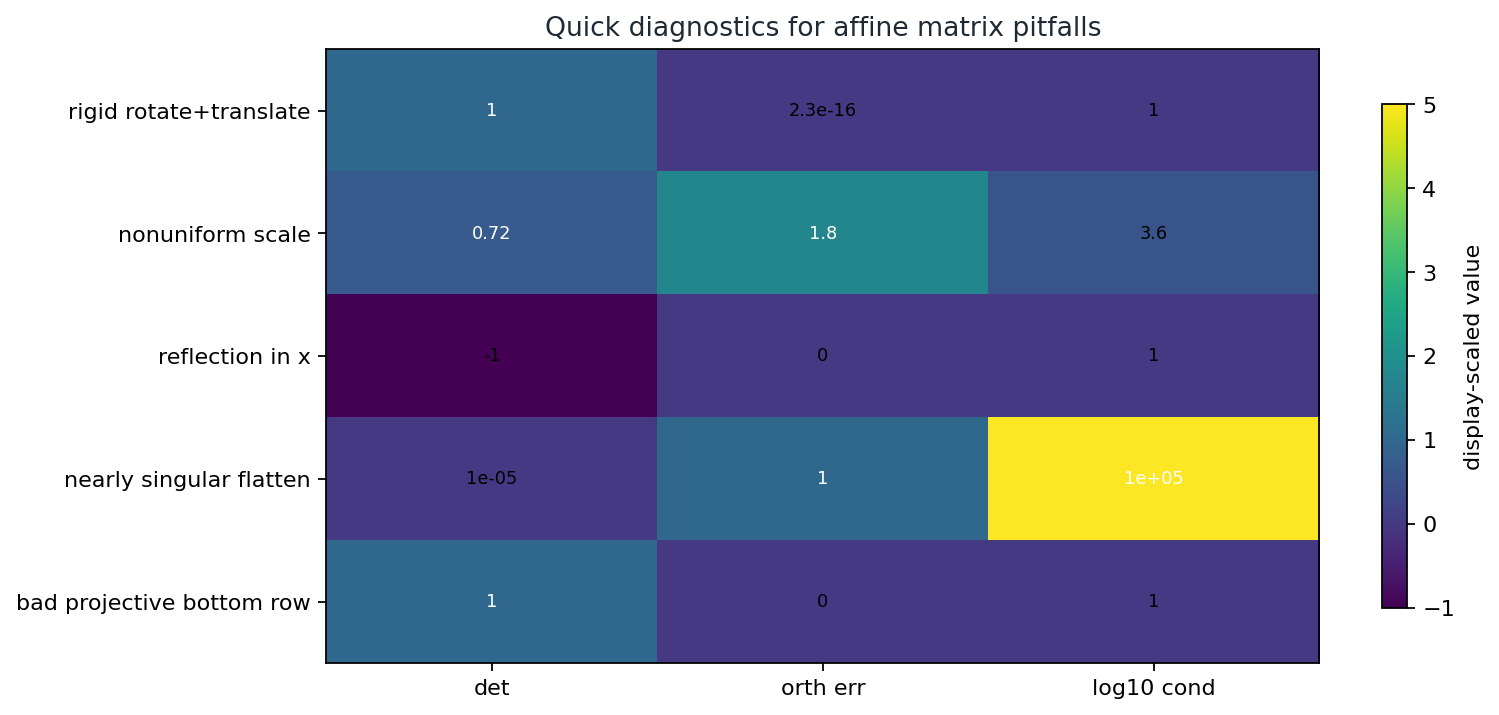

,matrix,determinant,orientation,affine_bottom_row,orthogonality_error,condition_number,rigid_linear_part,normal_transform_warning
0,rigid rotate+translate,1.00000,preserved,True,2.251940e-16,1.000000,True,False
1,nonuniform scale,0.72000,preserved,True,1.752029e+00,3.555556,False,True
2,reflection in x,-1.00000,flipped,True,0.000000e+00,1.000000,False,True
3,nearly singular flatten,0.00001,preserved,True,1.000000e+00,100000.000000,False,True
4,bad projective bottom row,1.00000,preserved,False,0.000000e+00,1.000000,True,False


In [9]:
def make_affine(A3: np.ndarray, t: np.ndarray) -> np.ndarray:
    M = np.eye(4)
    M[:3, :3] = A3
    M[:3, 3] = t
    return M


Rz = np.eye(3)
Rz[:2, :2] = rotation2(np.deg2rad(28))
matrices = {
    "rigid rotate+translate": make_affine(Rz, np.array([1.2, -0.4, 0.8])),
    "nonuniform scale": make_affine(np.diag([1.6, 0.45, 1.0]), np.array([0.0, 0.0, 0.0])),
    "reflection in x": make_affine(np.diag([-1.0, 1.0, 1.0]), np.array([0.2, 0.1, 0.0])),
    "nearly singular flatten": make_affine(np.diag([1.0, 1.0, 1e-5]), np.zeros(3)),
    "bad projective bottom row": make_affine(np.eye(3), np.zeros(3)),
}
matrices["bad projective bottom row"][3, 2] = 0.2

records = []
for name, M in matrices.items():
    A = M[:3, :3]
    det = float(np.linalg.det(A))
    affine_bottom = bool(np.allclose(M[3], np.array([0.0, 0.0, 0.0, 1.0])))
    orth_error = float(np.linalg.norm(A.T @ A - np.eye(3)))
    cond = float(np.linalg.cond(A))
    records.append({
        "matrix": name,
        "determinant": det,
        "orientation": "flipped" if det < 0 else "preserved",
        "affine_bottom_row": affine_bottom,
        "orthogonality_error": orth_error,
        "condition_number": cond,
        "rigid_linear_part": bool(abs(det - 1.0) < 1e-9 and orth_error < 1e-9),
        "normal_transform_warning": bool(orth_error > 1e-9 or det <= 0 or cond > 1e4),
    })

diagnostics = pd.DataFrame(records)
pitfall_table_path = save_table_csv(diagnostics.to_dict(orient="records"), TOPIC, "matrix-pitfall-diagnostics.csv")
ARTIFACTS.append(pitfall_table_path)

plot_df = diagnostics.set_index("matrix")[["determinant", "orthogonality_error", "condition_number"]].copy()
plot_values = plot_df.copy()
plot_values["condition_number"] = np.log10(plot_values["condition_number"].clip(lower=1.0))
fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(plot_values.to_numpy(), cmap="viridis", aspect="auto")
ax.set_xticks(range(plot_values.shape[1]), ["det", "orth err", "log10 cond"])
ax.set_yticks(range(plot_values.shape[0]), plot_values.index)
for i in range(plot_values.shape[0]):
    for j in range(plot_values.shape[1]):
        raw = plot_df.iloc[i, j]
        label = f"{raw:.2g}"
        ax.text(j, i, label, ha="center", va="center", color="white" if plot_values.iloc[i, j] > plot_values.to_numpy().mean() else "black", fontsize=8)
ax.set_title("Quick diagnostics for affine matrix pitfalls", color=PALETTE["ink"], fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.82, label="display-scaled value")
fig.tight_layout()
pitfall_fig_path = save_matplotlib(fig, TOPIC, "matrix-pitfall-diagnostics.png")
close(fig)
ARTIFACTS.append(pitfall_fig_path)

pitfall_checks = {
    "matrix_count": int(len(diagnostics)),
    "non_affine_bottom_rows": diagnostics.loc[~diagnostics["affine_bottom_row"], "matrix"].tolist(),
    "normal_transform_warning_count": int(diagnostics["normal_transform_warning"].sum()),
    "nearly_singular_condition_number": float(diagnostics.loc[diagnostics["matrix"] == "nearly singular flatten", "condition_number"].iloc[0]),
}
assert "bad projective bottom row" in pitfall_checks["non_affine_bottom_rows"]
assert pitfall_checks["normal_transform_warning_count"] >= 3
pitfall_check_path = save_json(pitfall_checks, TOPIC, "matrix-pitfall-checks.json")
ARTIFACTS.append(pitfall_check_path)

display_artifact(pitfall_fig_path, width=860)
display(diagnostics)
display_artifact(pitfall_table_path)
CHECKS["pitfalls"] = pitfall_checks

## Sanity checks

The checks below gather the chapter invariants into one executable cell. They are intentionally redundant with the earlier cells: final notebook validation should fail if an edit breaks a core transformation identity, deletes an artifact, or leaves a visual blank.

In [10]:
assert_close("rotation inverse is transpose", R.T @ R, np.eye(2), atol=1e-12)
assert_close("inverse reverses composition", np.linalg.inv(RS), np.linalg.inv(S) @ np.linalg.inv(R), atol=1e-12)
assert np.allclose(T2 @ direction_xy, direction_xy)
assert np.allclose(F_inv @ F, np.eye(3))
assert abs(np.dot(correct_n, Mt1)) < 1e-12 and abs(np.dot(correct_n, Mt2)) < 1e-12
assert abs(np.linalg.det(R_axis) - 1.0) < 1e-12

artifact_records = assert_artifacts(ARTIFACTS)
image_records = [assert_nonblank_image(path) for path in ARTIFACTS if Path(path).suffix.lower() == ".png"]

final_sanity = {
    "chapter": 7,
    "source_span": {"printed_pages": "127-156", "physical_pdf_pages": "144-173"},
    "artifact_count_excluding_final_sanity": len(artifact_records),
    "artifact_count_including_final_sanity": len(artifact_records) + 1,
    "png_count": len(image_records),
    "checks_recorded": sorted(CHECKS.keys()),
    "core_identities": {
        "rotation_inverse_transpose": True,
        "inverse_reverses_composition": True,
        "homogeneous_w_zero_ignores_translation": True,
        "frame_roundtrip": True,
        "normal_inverse_transpose": True,
        "axis_rotation_det_one": True,
    },
    "artifacts": artifact_records,
    "final_sanity_artifact": {"path": "artifacts/chapter-07/checks/final-sanity.json", "asserted_nonempty": True},
}
final_sanity_path = save_json(final_sanity, TOPIC, "final-sanity.json")
assert_artifacts([final_sanity_path])
ARTIFACTS.append(final_sanity_path)

display_artifact(final_sanity_path)
final_sanity

{'chapter': 7,
 'source_span': {'printed_pages': '127-156', 'physical_pdf_pages': '144-173'},
 'artifact_count_excluding_final_sanity': 18,
 'artifact_count_including_final_sanity': 19,
 'png_count': 7,
 'checks_recorded': ['axis_rotation',
  'composition',
  'decomposition',
  'frames',
  'homogeneous',
  'linear',
  'normal_transform',
  'pitfalls'],
 'core_identities': {'rotation_inverse_transpose': True,
  'inverse_reverses_composition': True,
  'homogeneous_w_zero_ignores_translation': True,
  'frame_roundtrip': True,
  'normal_inverse_transpose': True,
  'axis_rotation_det_one': True},
 'artifacts': [{'path': 'artifacts/chapter-07/figures/linear-map-basis-area.png',
   'bytes': 119453},
  {'path': 'artifacts/chapter-07/checks/linear-transform-invariants.json',
   'bytes': 245},
  {'path': 'artifacts/chapter-07/figures/composition-order-noncommuting.png',
   'bytes': 102191},
  {'path': 'artifacts/chapter-07/checks/composition-order-checks.json',
   'bytes': 202},
  {'path': 'arti

## Takeaways

A transformation matrix is a compact geometric claim. Its columns tell where basis vectors go, its determinant tells signed area or volume scale, and its inverse tells how to undo the coordinate story it encodes. Homogeneous coordinates let translations join the same matrix algebra as rotations, scales, and shears, but only if points and directions keep different final coordinates.

The most useful debugging habits from this chapter are simple and mechanical: label the coordinate frame of every vector, read products from right to left, check whether a matrix is affine before treating it as one, use the transpose as the inverse only for orthogonal rotations, and transform normals with the inverse transpose whenever the linear part is not a pure rotation.